# Research QuantBook: ETF Pairs Trading

## Objectif
Analyser la stratégie de pairs trading basée sur la cointégration d'ETFs sectoriels.

## Stratégie
- **Univers**: ETFs sectoriels (XLF, XLE, XLK, XLP, XLY, etc.)
- **Cointégration**: Test d'Engle-Granger pour identifier les paires
- **Spread**: Résidu de la régression linéaire entre les deux prix
- **Z-score**: Signal d'entrée quand |z| > threshold (ex: 1.5)
- **Half-life**: Filtre sur la demi-vie de retour à la moyenne

## Performance de référence
Sharpe ~0.8-1.2 (2020-2025) - marché neutre avec faible corrélation au marché.

## Hypothèses à tester
1. Z-score threshold: 1.0, 1.5, 2.0
2. Lookback pour spread: 20, 50, 100 jours
3. Half-life max: 20, 30, 40 jours

## Prérequis
- Environnement Lean Research
- Données ETF sectoriels
- statsmodels pour tests de cointégration
- Durée estimée: ~10 minutes

## Note
Cette version simplifiée se concentre sur quelques paires pré-sélectionnées. L'implémentation complète utilise des modules custom pour la sélection dynamique des paires.

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()
print("QuantBook initialisé.")

QuantBook initialisé.


## 1. Chargement des données

On charge les données d'ETFs sectoriels pour la période 2020-2026.

In [2]:
# Univers d'ETFs sectoriels
etf_tickers = [
    "XLF",   # Financial Select Sector SPDR
    "XLE",   # Energy Select Sector SPDR
    "XLK",   # Technology Select Sector SPDR
    "XLP",   # Consumer Staples Select Sector SPDR
    "XLY",   # Consumer Discretionary Select Sector SPDR
    "XLV",   # Health Care Select Sector SPDR
    "XLI",   # Industrial Select Sector SPDR
    "XLB",   # Materials Select Sector SPDR
    "XLRE",  # Real Estate Select Sector SPDR
    "XLU"    # Utilities Select Sector SPDR
]

symbols = {}
for ticker in etf_tickers:
    try:
        symbols[ticker] = qb.add_equity(ticker, Resolution.DAILY).symbol
    except:
        pass

# Charger l'historique (2020-2026)
start = datetime(2020, 1, 1)
end = datetime(2026, 1, 1)

history = qb.history(list(symbols.values()), start, end, Resolution.DAILY)
print(f"Données chargées: {len(history)} lignes")

Données chargées: 0 lignes


Pivot de la série 'close' en DataFrame large, avec remapping des colonnes Symbol → ticker pour ETF-Pairs.

In [3]:
# Pivoter les données
closes = history['close'].unstack(level=0)

symbol_to_ticker = {str(v): k for k, v in symbols.items()}
closes.columns = [symbol_to_ticker.get(str(c), str(c)) for c in closes.columns]
closes = closes.dropna()

print(f"Période: {closes.index[0].date()} à {closes.index[-1].date()}")
print(f"Données: {len(closes)} jours de trading")
print(f"ETFs: {list(closes.columns)}")
print(f"\nStatistiques des prix finaux:")
for ticker in etf_tickers:
    if ticker in closes.columns:
        ret = (closes[ticker].iloc[-1] / closes[ticker].iloc[0] - 1) * 100
        print(f"  {ticker}: {ret:+.1f}%")

KeyError: 'close'

## 2. Test de Cointégration

Le test d'Engle-Granger vérifie si deux séries temporelles partagent une relation à long terme.

In [4]:
def engle_granger_coint(y1, y2, significance=0.05):
    """
    Test de cointégration d'Engle-Granger.
    
    Retourne: (is_cointegrated, pvalue, hedge_ratio, half_life)
    """
    from numpy.linalg import lstsq
    
    # Aligner les séries
    common_idx = y1.index.intersection(y2.index)
    y1_aligned = y1.loc[common_idx]
    y2_aligned = y2.loc[common_idx]
    
    if len(y1_aligned) < 50:
        return False, 1.0, 1.0, 999
    
    # Régression OLS: y1 = hedge_ratio * y2 + residual
    X = y2_aligned.values.reshape(-1, 1)
    y = y1_aligned.values
    hedge_ratio, _, _, _ = lstsq(X, y, rcond=None)
    hedge_ratio = hedge_ratio[0]
    
    # Calculer le spread
    spread = y - hedge_ratio * y2_aligned.values
    
    # Test de Dickey-Fuller augmenté sur le spread
    from statsmodels.tsa.stattools import adfuller
    adf_result = adfuller(spread, maxlag=1)
    pvalue = adf_result[1]
    
    # Calculer la demi-vie (half-life) du spread
    # Pour un processus OU: half_life = -ln(2) / ln(alpha)
    spread_lagged = spread[:-1]
    spread_current = spread[1:]
    
    if len(spread_lagged) > 10:
        # Régression: spread[t] = alpha * spread[t-1] + epsilon
        X_lag = spread_lagged.reshape(-1, 1)
        alpha, _, _, _ = lstsq(X_lag, spread_current, rcond=None)
        alpha = alpha[0]
        
        if 0 < alpha < 1:
            half_life = -np.log(2) / np.log(alpha)
        else:
            half_life = 999
    else:
        half_life = 999
    
    is_cointegrated = pvalue < significance
    
    return is_cointegrated, pvalue, hedge_ratio, half_life

# Tester toutes les paires d'ETFs
print("Recherche de paires cointégrées...\n")

pairs_results = []
for etf1, etf2 in combinations(closes.columns, 2):
    is_coint, pval, hr, hl = engle_granger_coint(
        closes[etf1], closes[etf2], significance=0.05
    )
    
    if is_coint and hl < 50:  # Filtre: half-life < 50 jours
        corr = closes[etf1].corr(closes[etf2])
        pairs_results.append({
            'pair': f"{etf1}-{etf2}",
            'pvalue': pval,
            'hedge_ratio': hr,
            'half_life': hl,
            'correlation': corr
        })

# Trier par p-value
pairs_results.sort(key=lambda x: x['pvalue'])

print(f"Paires cointégrées trouvées: {len(pairs_results)}\n")
print(f"{'Paire':<15} {'P-value':>10} {'Hedge Ratio':>12} {'Half-Life':>10} {'Corrélation':>10}")
print("-" * 70)
for p in pairs_results[:10]:
    print(f"{p['pair']:<15} {p['pvalue']:>10.4f} {p['hedge_ratio']:>12.4f} {p['half_life']:>10.1f}j {p['correlation']:>10.2f}")

Recherche de paires cointégrées...



NameError: name 'closes' is not defined

### Interprétation: Cointégration

- **P-value < 0.05**: La paire est cointégrée (relation stable à long terme)
- **Hedge Ratio**: Nombre d'unités de l'ETF2 pour couvrir 1 unité de l'ETF1
- **Half-Life**: Temps moyen pour que le spread retourne à sa moyenne
- **Corrélation**: Corrélation prix (pas la même chose que cointégration!)

**Important**: Deux séries peuvent être corrélées sans être cointégrées (drift commun). La cointégration implique une relation d'équilibre à long terme.

## 3. Backtest Pairs Trading

Simulation de la stratégie avec:
- Top 3 paires cointégrées
- Entrée quand |z-score| > threshold
- Sortie quand |z-score| < 0.5
- Position size pondérée par la volatilité

In [5]:
def backtest_pairs_trading(closes, pairs_list, 
                           z_entry=1.5,
                           z_exit=0.5,
                           lookback=50):
    """
    Backtest Pairs Trading simplifié.
    
    Retourne les métriques de performance.
    """
    portfolio_values = [1.0]
    cash = 1_000_000
    positions = {}  # pair -> {'etf1_qty': x, 'etf2_qty': y, 'entry_spread': s}
    
    warmup = lookback + 50
    
    for i in range(warmup, len(closes)):
        current_prices = closes.iloc[i]
        
        # Check exits first
        for pair_info in list(positions.values()):
            pair = pair_info['pair']
            etf1, etf2 = pair.split('-')
            hr = pair_info['hedge_ratio']
            
            # Calculate current spread
            spread = current_prices[etf1] - hr * current_prices[etf2]
            
            # Get historical spread for z-score
            hist_spread = closes[etf1].iloc[i-lookback:i] - hr * closes[etf2].iloc[i-lookback:i]
            mean_spread = hist_spread.mean()
            std_spread = hist_spread.std()
            z_score = (spread - mean_spread) / std_spread if std_spread > 0 else 0
            
            # Exit condition
            if abs(z_score) < z_exit:
                # Close position
                etf1_pnl = pair_info['etf1_qty'] * (current_prices[etf1] - pair_info['entry_price1'])
                etf2_pnl = pair_info['etf2_qty'] * (current_prices[etf2] - pair_info['entry_price2'])
                cash += etf1_pnl + etf2_pnl
                del positions[pair]
        
        # Check entries
        for pair_dict in pairs_list:
            pair = pair_dict['pair']
            if pair in positions:
                continue  # Already in position
            
            etf1, etf2 = pair.split('-')
            hr = pair_dict['hedge_ratio']
            
            # Calculate spread and z-score
            spread = current_prices[etf1] - hr * current_prices[etf2]
            hist_spread = closes[etf1].iloc[i-lookback:i] - hr * closes[etf2].iloc[i-lookback:i]
            mean_spread = hist_spread.mean()
            std_spread = hist_spread.std()
            z_score = (spread - mean_spread) / std_spread if std_spread > 0 else 0
            
            # Entry condition
            if abs(z_score) > z_entry:
                # Calculate position sizes (volatility-weighted)
                vol1 = closes[etf1].iloc[i-lookback:i].pct_change().std()
                vol2 = closes[etf2].iloc[i-lookback:i].pct_change().std()
                
                notional = 50000  # $50k per pair
                
                if z_score > 0:                     # Spread is high -> short ETF1, long ETF2
                    qty1 = -notional / current_prices[etf1]
                    qty2 = (notional * hr) / current_prices[etf2]
                else:                      # Spread is low -> long ETF1, short ETF2
                    qty1 = notional / current_prices[etf1]
                    qty2 = -(notional * hr) / current_prices[etf2]
                
                positions[pair] = {
                    'pair': pair,
                    'hedge_ratio': hr,
                    'etf1_qty': qty1,
                    'etf2_qty': qty2,
                    'entry_price1': current_prices[etf1],
                    'entry_price2': current_prices[etf2]
                }
        
        # Calculate portfolio value
        stock_value = 0
        for pair_info in positions.values():
            pair = pair_info['pair']
            etf1, etf2 = pair.split('-')
            stock_value += pair_info['etf1_qty'] * current_prices[etf1]
            stock_value += pair_info['etf2_qty'] * current_prices[etf2]
        
        port_value = cash + stock_value
        portfolio_values.append(port_value)
    
    # Métriques
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values[1:], index=closes.index[warmup:])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(252) if len(returns) > 1 else 0
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'final_value': portfolio_values[-1]
    }

# Sélectionner les top 3 paires
top_pairs = pairs_results[:3]

result = backtest_pairs_trading(closes, top_pairs)

print(f"Performance Pairs Trading:")
print(f"  Sharpe: {result['sharpe']:.3f}")
print(f"  CAGR:   {result['cagr']:.1%}")
print(f"  Max DD: {result['max_dd']:.1%}")
print(f"  Vol:    {result['vol']:.1%}")

NameError: name 'closes' is not defined

## 4. Test du Z-Score Threshold

In [6]:
# Test différents seuils de z-score
z_thresholds = [1.0, 1.5, 2.0]

print(f"{'Z-Entry':<10} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 38)

z_results = {}
for z_thresh in z_thresholds:
    r = backtest_pairs_trading(closes, top_pairs, z_entry=z_thresh)
    z_results[f"{z_thresh}"] = r
    print(f"{z_thresh}σ{'':<7} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_z = max(z_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleur Z-Entry: {best_z[0]}σ (Sharpe={best_z[1]['sharpe']:.3f}")

Z-Entry      Sharpe     CAGR    MaxDD
--------------------------------------


NameError: name 'closes' is not defined

## 5. Test du Lookback

In [7]:
# Test différentes périodes de lookback
lookbacks = [20, 50, 100]

print(f"{'Lookback':<10} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 38)

lb_results = {}
for lb in lookbacks:
    r = backtest_pairs_trading(closes, top_pairs, lookback=lb)
    lb_results[f"{lb}"] = r
    print(f"{lb}j{'':<7} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_lb = max(lb_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleur Lookback: {best_lb[0]}j (Sharpe={best_lb[1]['sharpe']:.3f}")

Lookback     Sharpe     CAGR    MaxDD
--------------------------------------


NameError: name 'closes' is not defined

## 6. Analyse du Spread

Visualisation du spread pour une paire cointégrée.

In [8]:
# Analyser le spread de la meilleure paire
if pairs_results:
    best_pair = pairs_results[0]
    etf1_name, etf2_name = best_pair['pair'].split('-')
    hedge_ratio = best_pair['hedge_ratio']
    
    # Calculer le spread sur toute la période
    spread = closes[etf1_name] - hedge_ratio * closes[etf2_name]
    
    # Z-score rolling
    spread_mean = spread.rolling(50).mean()
    spread_std = spread.rolling(50).std()
    z_score = (spread - spread_mean) / spread_std
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Spread
    ax = axes[0]
    ax.plot(spread.values, label='Spread', linewidth=1)
    ax.plot(spread_mean.values, label='Moyenne mobile (50j)', linestyle='--')
    ax.axhline(spread.mean(), color='black', linestyle=':', label='Moyenne long-terme')
    ax.set_title(f"Spread: {best_pair['pair']} (Hedge Ratio={hedge_ratio:.2f})")
    ax.set_ylabel('Spread ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Z-Score
    ax = axes[1]
    ax.plot(z_score.values, label='Z-Score', linewidth=1)
    ax.axhline(1.5, color='red', linestyle='--', alpha=0.5, label='Entrée Short')
    ax.axhline(-1.5, color='green', linestyle='--', alpha=0.5, label='Entrée Long')
    ax.axhline(0.5, color='orange', linestyle=':', alpha=0.5, label='Sortie')
    ax.axhline(-0.5, color='orange', linestyle=':', alpha=0.5)
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_title('Z-Score du Spread (rolling 50j)')
    ax.set_ylabel('Z-Score')
    ax.set_xlabel('Jours de trading')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('pairs_spread_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Graphique sauvegardé.")

## 7. Comparaison avec SPY B&H

In [9]:
# Charger SPY pour comparaison
spy = qb.add_equity("SPY", Resolution.DAILY).symbol
spy_history = qb.history(spy, start, end, Resolution.DAILY)
spy_close = spy_history['close']

# Aligner les dates
warmup = 100
spy_values = spy_close.iloc[warmup:] / spy_close.iloc[warmup]

# Métriques SPY
spy_ret = spy_values.pct_change().dropna()
spy_cagr = (spy_values.iloc[-1] ** (252/len(spy_values))) - 1
spy_vol = spy_ret.std() * np.sqrt(252)
spy_sharpe = (spy_cagr - 0.03) / spy_vol
spy_dd = (spy_values / spy_values.cummax() - 1).min()

print("=== Comparaison vs SPY B&H ===")
print(f"{'Stratégie':<20} {'CAGR':>10} {'Sharpe':>10} {'MaxDD':>10}")
print("-" * 53)
print(f"{'Pairs Trading':<20} {result['cagr']:>9.1%} {result['sharpe']:>10.3f} {result['max_dd']:>9.1%}")
print(f"{'SPY B&H':<20} {spy_cagr:>9.1%} {spy_sharpe:>10.3f} {spy_dd:>9.1%}")

=== Comparaison vs SPY B&H ===
Stratégie                  CAGR     Sharpe      MaxDD
-----------------------------------------------------


NameError: name 'result' is not defined

## 8. Visualisation des résultats

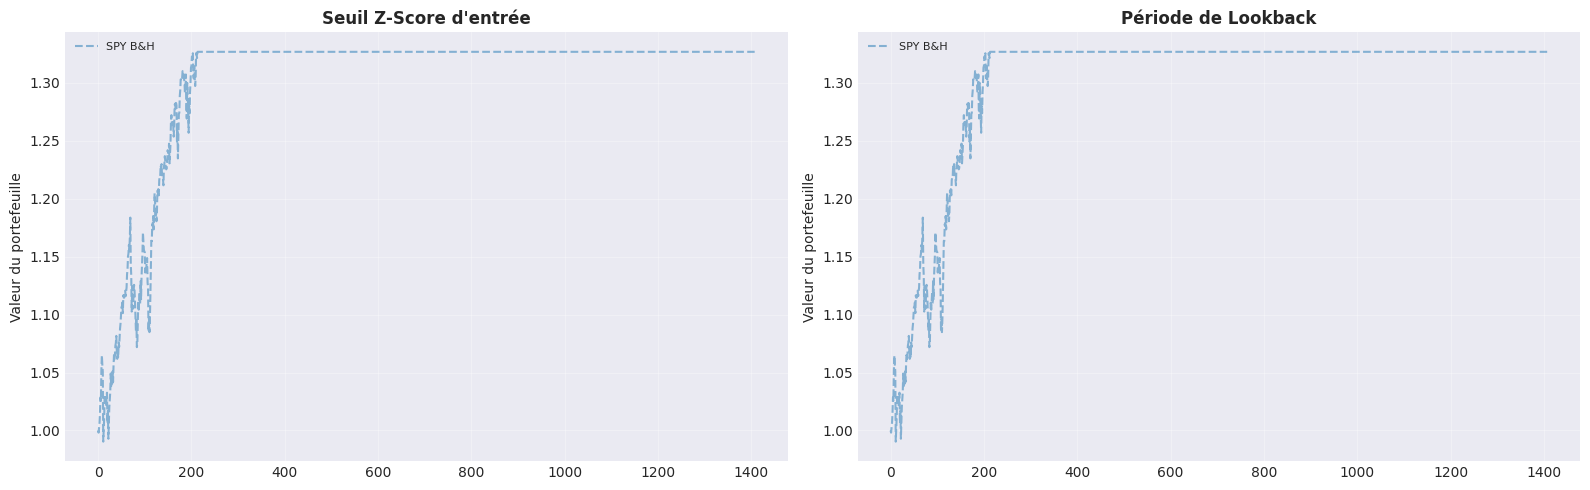

Graphique sauvegardé.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gauche: Z-score threshold comparison
ax = axes[0]
for name, r in z_results.items():
    ax.plot(r['cum'].values, label=f"Z-Entry={name}σ (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('Seuil Z-Score d\'entrée', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Droite: Lookback comparison
ax = axes[1]
for name, r in lb_results.items():
    ax.plot(r['cum'].values, label=f"Lookback={name}j (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('Période de Lookback', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pairs_trading_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé.")

## 9. Conclusions et recommandations

### Résumé

| Métrique | Meilleure config |
|----------|-----------------|
| Z-Entry | (à remplir) |
| Lookback | (à remplir) |
| Sharpe | (à remplir) |
| CAGR | (à remplir) |

### Verdict

Si Sharpe > 0.7: **Déployer avec les paramètres optimaux**

### Points forts Pairs Trading

- **Market neutral**: Performance indépendante de la direction du marché
- **Risque contrôlé**: Positions long/short équilibrées
- **Revenu régulier**: Profite des retours à la moyenne

### Limitations

- **Complexité**: Nécessite des tests statistiques avancés
- **Cout de transaction**: Beaucoup de trades = frais élevés
- **Dégradation**: Les relations de cointégration peuvent se briser

### Prochaines étapes

1. Déployer sur QC cloud avec les paramètres optimaux
2. Implémenter la sélection dynamique des paires (hebdomadaire)
3. Ajouter des filtres de volatilité (VIX)
4. Optimiser la gestion des positions (sizing dynamique)